In [1]:
#Import libraries and check GPU availability
import os
import torch
import clip
from PIL import Image
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pickle
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"🐍 Python version: {torch.__version__}")
print("✅ All imports successful!")

🖥️  Using device: cuda
   GPU: NVIDIA GeForce RTX 4080 SUPER
🐍 Python version: 2.8.0+cu128
✅ All imports successful!


In [2]:
# Try to import CLIP with error handling
try:
    import clip
    print("✅ CLIP imported successfully")
    
    # Test if clip.load works
    available_models = clip.available_models()
    print(f"📋 Available CLIP models: {available_models[:3]}...")  # Show first 3
    
except ImportError as e:
    print("❌ CLIP import failed!")
    print(f"Error: {e}")
    print("\n🔧 SOLUTION:")
    print("1. Run: !pip uninstall clip clipy clip-by-openai -y")
    print("2. Run: !pip install git+https://github.com/openai/CLIP.git")
    print("3. Restart your kernel")
    raise ImportError("Please fix CLIP installation before continuing")

except AttributeError as e:
    print("❌ CLIP module doesn't have 'load' attribute!")
    print(f"Error: {e}")
    print("\n🔧 SOLUTION:")
    print("You likely have the wrong CLIP package installed.")
    print("1. Run: !pip uninstall clip clipy clip-by-openai -y")
    print("2. Run: !pip install git+https://github.com/openai/CLIP.git")
    print("3. Restart your kernel")
    raise ImportError("Please fix CLIP installation before continuing")

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"🐍 PyTorch version: {torch.__version__}")
print("✅ All imports successful!")

✅ CLIP imported successfully
📋 Available CLIP models: ['RN50', 'RN101', 'RN50x4']...
🖥️  Using device: cuda
   GPU: NVIDIA GeForce RTX 4080 SUPER
🐍 PyTorch version: 2.8.0+cu128
✅ All imports successful!


In [3]:
images_folder = "/home/slakkaraju/flowers/flowers"

# Verify the folder exists
if os.path.exists(images_folder):
    print(f"✅ Found images folder: {images_folder}")
    
    # Count images
    supported_formats = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    image_files = [f for f in os.listdir(images_folder) 
                   if any(f.lower().endswith(fmt) for fmt in supported_formats)]
    print(f"📸 Found {len(image_files)} images")
    
    # Show first few filenames as examples
    if image_files:
        print("📋 Sample files:")
        for i, filename in enumerate(image_files[:5]):
            print(f"   {i+1}. {filename}")
        if len(image_files) > 5:
            print(f"   ... and {len(image_files) - 5} more")
else:
    print(f"❌ Folder not found: {images_folder}")
    print("Please update the 'images_folder' variable with the correct path to your images")

✅ Found images folder: /home/slakkaraju/flowers/flowers
📸 Found 13862 images
📋 Sample files:
   1. image_00298.jpg
   2. image_04578.jpg
   3. 2683330456_0f7bbce110_m.jpg
   4. 145303599_2627e23815_n.jpg
   5. image_0565.jpg
   ... and 13857 more


In [4]:
#Load CLIP Model

print("🔄 Loading CLIP model...")

# You can change the model here:
# "ViT-B/32" - Fast, good quality (default)
# "ViT-B/16" - Slower, better quality  
# "ViT-L/14" - Slowest, best quality
model_name = "ViT-B/32"

model, preprocess = clip.load(model_name, device=device)
print(f"✅ Loaded CLIP model: {model_name}")
print(f"📊 Model parameters: ~{sum(p.numel() for p in model.parameters()):,}")

🔄 Loading CLIP model...


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 101MiB/s]


✅ Loaded CLIP model: ViT-B/32
📊 Model parameters: ~151,277,313


In [ ]:
#Helper functions for display
def load_image_paths(folder):
    """Load all image paths from folder"""
    supported_formats = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    paths = []
    for filename in os.listdir(folder):
        if any(filename.lower().endswith(fmt) for fmt in supported_formats):
            paths.append(os.path.join(folder, filename))
    return sorted(paths)

def display_results(query, results, max_display=3):
    """Display search results with images"""
    print(f"\n🔍 Query: '{query}'")
    print("=" * 50)
    
    fig, axes = plt.subplots(1, min(len(results), max_display), figsize=(15, 5))
    if len(results) == 1:
        axes = [axes]
    
    for i, (image_path, score) in enumerate(results[:max_display]):
        # Load and display image
        img = Image.open(image_path)
        
        if len(results) > 1:
            axes[i].imshow(img)
            axes[i].set_title(f"#{i+1}: {os.path.basename(image_path)}\nSimilarity: {score:.3f}", 
                            fontsize=10)
            axes[i].axis('off')
        else:
            axes[0].imshow(img)
            axes[0].set_title(f"#{i+1}: {os.path.basename(image_path)}\nSimilarity: {score:.3f}", 
                            fontsize=10)
            axes[0].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print all results
    print("\n📋 All results:")
    for i, (image_path, score) in enumerate(results, 1):
        filename = os.path.basename(image_path)
        print(f"   {i}. {filename} (similarity: {score:.3f})")

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


In [6]:
#Compute Image Embeddings
def compute_image_embeddings(images_folder, force_recompute=False):
    """Compute embeddings for all images"""
    cache_file = os.path.join(images_folder, "embeddings_cache.pkl")
    
    # Check for cached embeddings
    if os.path.exists(cache_file) and not force_recompute:
        print("🔄 Loading cached embeddings...")
        with open(cache_file, 'rb') as f:
            cache_data = pickle.load(f)
        print("✅ Cached embeddings loaded!")
        return cache_data['embeddings'], cache_data['paths']
    
    # Load image paths
    image_paths = load_image_paths(images_folder)
    print(f"🔄 Computing embeddings for {len(image_paths)} images...")
    
    embeddings = []
    successful_paths = []
    
    for i, image_path in enumerate(image_paths):
        try:
            # Load and preprocess image
            image = Image.open(image_path).convert('RGB')
            image_tensor = preprocess(image).unsqueeze(0).to(device)
            
            # Get embedding
            with torch.no_grad():
                embedding = model.encode_image(image_tensor)
                embedding = embedding / embedding.norm(dim=-1, keepdim=True)
            
            embeddings.append(embedding.cpu().numpy())
            successful_paths.append(image_path)
            
            # Progress update
            if (i + 1) % 10 == 0 or i == len(image_paths) - 1:
                print(f"   Progress: {i + 1}/{len(image_paths)} ({100*(i+1)/len(image_paths):.1f}%)")
                
        except Exception as e:
            print(f"   ⚠️  Error processing {os.path.basename(image_path)}: {str(e)}")
    
    if not embeddings:
        raise ValueError("No images could be processed successfully")
    
    embeddings_array = np.vstack(embeddings)
    
    # Cache the results
    print("💾 Caching embeddings...")
    cache_data = {
        'embeddings': embeddings_array,
        'paths': successful_paths
    }
    with open(cache_file, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"✅ Successfully processed {len(embeddings)} images!")
    return embeddings_array, successful_paths

# Run the embedding computation
# Set force_recompute=True if you want to recompute embeddings
image_embeddings, image_paths = compute_image_embeddings(images_folder, force_recompute=False)

🔄 Computing embeddings for 13862 images...
   Progress: 10/13862 (0.1%)
   Progress: 20/13862 (0.1%)
   Progress: 30/13862 (0.2%)
   Progress: 40/13862 (0.3%)
   Progress: 50/13862 (0.4%)
   Progress: 60/13862 (0.4%)
   Progress: 70/13862 (0.5%)
   Progress: 80/13862 (0.6%)
   Progress: 90/13862 (0.6%)
   Progress: 100/13862 (0.7%)
   Progress: 110/13862 (0.8%)
   Progress: 120/13862 (0.9%)
   Progress: 130/13862 (0.9%)
   Progress: 140/13862 (1.0%)
   Progress: 150/13862 (1.1%)
   Progress: 160/13862 (1.2%)
   Progress: 170/13862 (1.2%)
   Progress: 180/13862 (1.3%)
   Progress: 190/13862 (1.4%)
   Progress: 200/13862 (1.4%)
   Progress: 210/13862 (1.5%)
   Progress: 220/13862 (1.6%)
   Progress: 230/13862 (1.7%)
   Progress: 240/13862 (1.7%)
   Progress: 250/13862 (1.8%)
   Progress: 260/13862 (1.9%)
   Progress: 270/13862 (1.9%)
   Progress: 280/13862 (2.0%)
   Progress: 290/13862 (2.1%)
   Progress: 300/13862 (2.2%)
   Progress: 310/13862 (2.2%)
   Progress: 320/13862 (2.3%)
   Pro

In [7]:
#Text Search Function
def search_images(query, top_k=5):
    """Search for images similar to text query"""
    # Encode the text query
    text_tokens = clip.tokenize([query]).to(device)
    
    with torch.no_grad():
        text_embedding = model.encode_text(text_tokens)
        text_embedding = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
    
    # Calculate similarities
    similarities = cosine_similarity(text_embedding.cpu().numpy(), image_embeddings)[0]
    
    # Get top-k results
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        image_path = image_paths[idx]
        score = similarities[idx]
        results.append((image_path, float(score)))
    
    return results

print("✅ Search function ready!")

✅ Search function ready!


🔍 Searching for: 'a pink rose'

🔍 Query: 'a pink rose'


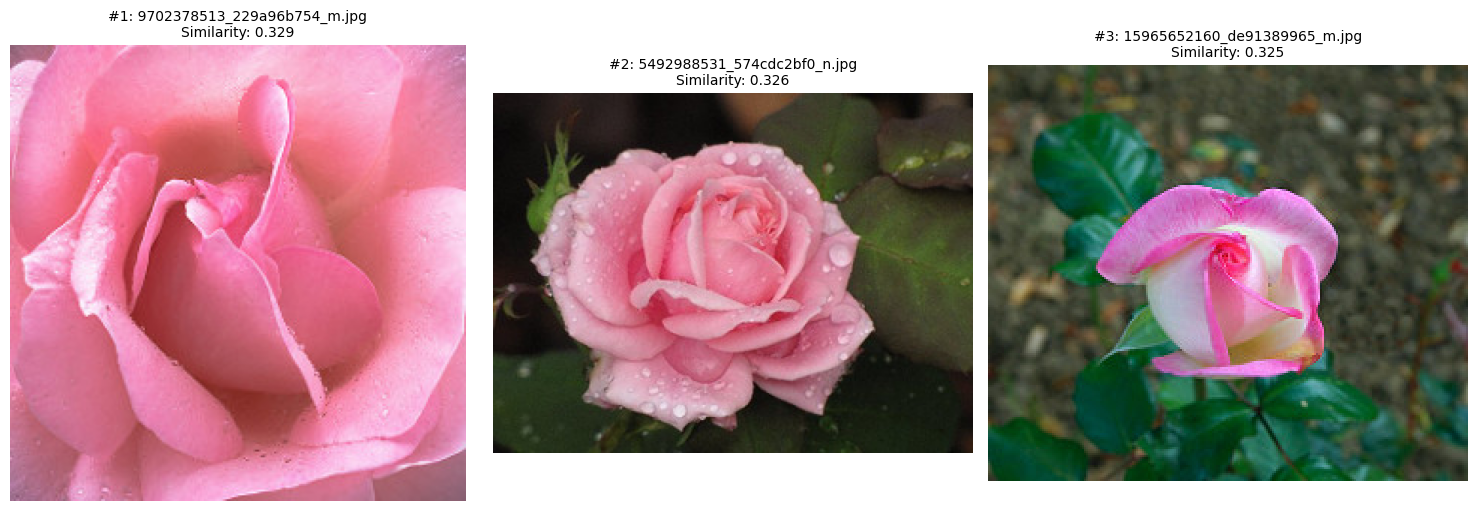


📋 All results:
   1. 9702378513_229a96b754_m.jpg (similarity: 0.329)
   2. 5492988531_574cdc2bf0_n.jpg (similarity: 0.326)
   3. 15965652160_de91389965_m.jpg (similarity: 0.325)
   4. 5159317458_bbb22e2f65_n.jpg (similarity: 0.323)
   5. 3667366832_7a8017c528_n.jpg (similarity: 0.323)


In [ ]:
#Single search
test_query = "a pink rose"

print(f"🔍 Searching for: '{test_query}'")
results = search_images(test_query, top_k=5)

# Display results
display_results(test_query, results, max_display=3)

🎯 Testing multiple queries...
You can modify the search_queries list above to test your own queries!

🔍 Query: 'red car'


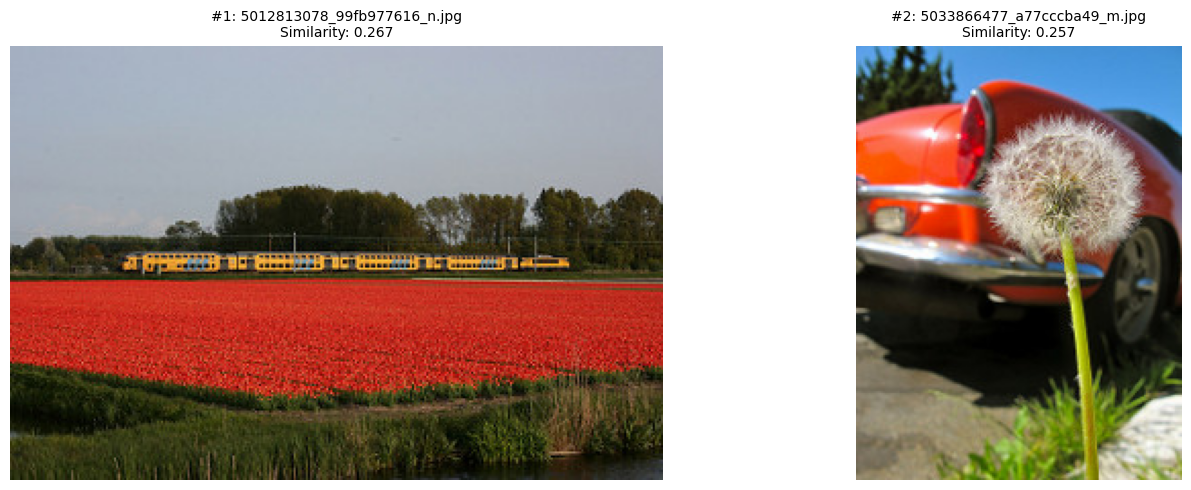


📋 All results:
   1. 5012813078_99fb977616_n.jpg (similarity: 0.267)
   2. 5033866477_a77cccba49_m.jpg (similarity: 0.257)
   3. 15275504998_ca9eb82998.jpg (similarity: 0.250)
   4. 15275190769_0ed7bbf490.jpg (similarity: 0.241)
   5. 6056460102_f5569092a6_n.jpg (similarity: 0.241)
   6. 7082608511_f4cf233f59_n.jpg (similarity: 0.238)

🔍 Query: 'flowers in garden'


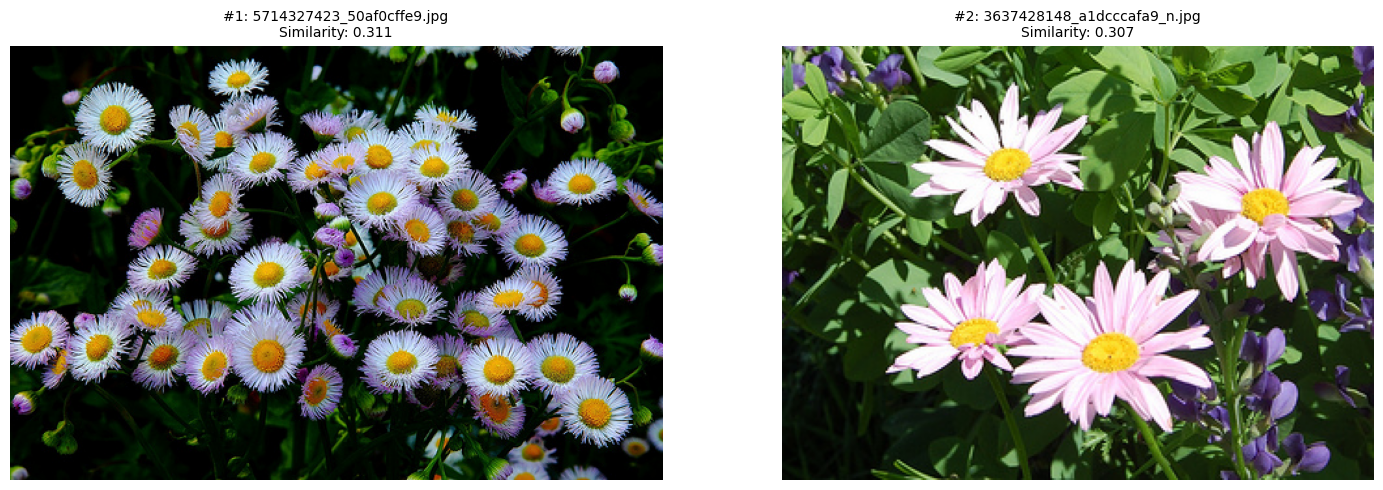


📋 All results:
   1. 5714327423_50af0cffe9.jpg (similarity: 0.311)
   2. 3637428148_a1dcccafa9_n.jpg (similarity: 0.307)
   3. image_05619.jpg (similarity: 0.304)
   4. 13997627965_22d81601ce_n.jpg (similarity: 0.304)
   5. 14332947164_9b13513c71_m.jpg (similarity: 0.302)
   6. 34637970155_a2b917077c_n.jpg (similarity: 0.302)

🔍 Query: 'building architecture'


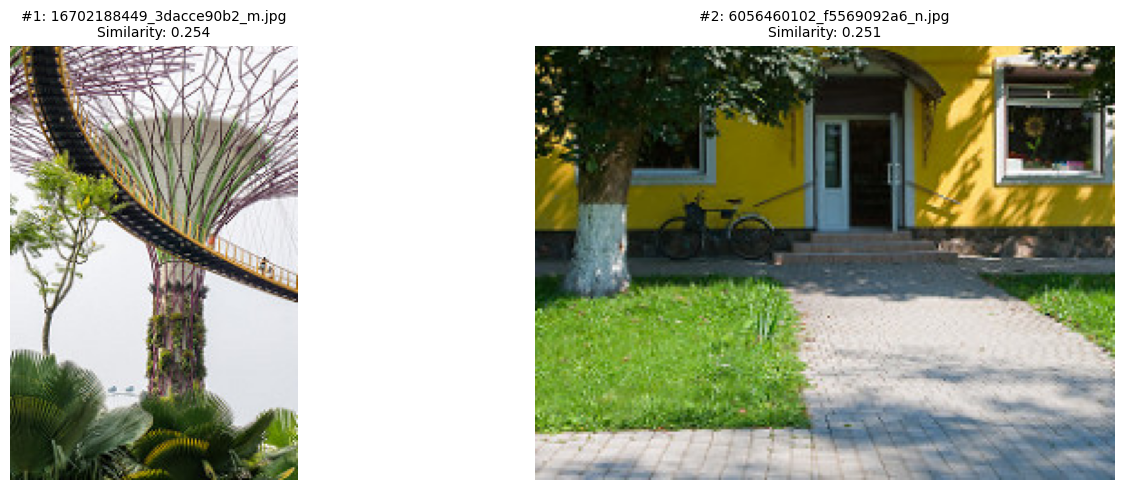


📋 All results:
   1. 16702188449_3dacce90b2_m.jpg (similarity: 0.254)
   2. 6056460102_f5569092a6_n.jpg (similarity: 0.251)
   3. 28664252816_1f24388ee6_n.jpg (similarity: 0.245)
   4. 13555215723_cf2c11626b_b.jpg (similarity: 0.245)
   5. 15275504998_ca9eb82998.jpg (similarity: 0.242)
   6. 16153267338_2f39906bcb_n.jpg (similarity: 0.240)


In [12]:
search_queries = [
    "a dog playing",
    "beautiful sunset",
    "person smiling", 
    "red car",
    "flowers in garden",
    "building architecture",
    "food on plate",
    "mountain landscape"
]

print("🎯 Testing multiple queries...")
print("You can modify the search_queries list above to test your own queries!")

for query in search_queries[3:6]:  # Show first 3 queries
    results = search_images(query, top_k=6)
    display_results(query, results, max_display=2)

In [ ]:
#Analyze how well different query types work
def analyze_collection(num_samples=5):
    """Analyze what types of images work best"""
    print("📊 ANALYZING YOUR IMAGE COLLECTION")
    print("=" * 40)
    
    # Test different types of queries
    test_categories = [
        ("Animals", ["cat", "dog", "bird", "horse"]),
        ("Nature", ["tree", "flower", "mountain", "beach"]),
        ("Objects", ["car", "chair", "book", "phone"]), 
        ("People", ["person", "face", "child", "woman"]),
        ("Food", ["pizza", "cake", "fruit", "coffee"]),
        ("Colors", ["red", "blue", "colorful", "bright"])
    ]
    
    for category, queries in test_categories:
        print(f"\n🏷️  {category}:")
        for query in queries[:2]:  # Test 2 queries per category
            results = search_images(query, top_k=3)
            if results:
                best_score = results[0][1]
                print(f"   '{query}': Best match = {best_score:.3f}")
                if best_score > 0.25:
                    print(f"      ✅ Good matches found!")
                elif best_score > 0.15:
                    print(f"      🟡 Moderate matches")
                else:
                    print(f"      ❌ Weak matches - might not have this type of image")

analyze_collection()

In [ ]:
#Explore Sample embeddings
def explore_embeddings():
    """Examine what embeddings look like and how they work"""
    print("🔬 EXPLORING EMBEDDINGS")
    print("=" * 40)
    
    # 1. Look at embedding dimensions
    print(f"📐 Embedding dimensions: {image_embeddings.shape}")
    print(f"   • {image_embeddings.shape[0]} images")
    print(f"   • {image_embeddings.shape[1]} features per embedding")
    
    # 2. Sample a few embeddings
    print(f"\n📊 Sample embedding values (first image, first 10 features):")
    sample_embedding = image_embeddings[0][:10]
    for i, val in enumerate(sample_embedding):
        print(f"   Feature {i+1:2d}: {val:8.4f}")
    
    print(f"\n📈 Embedding statistics:")
    print(f"   • Min value: {image_embeddings.min():.4f}")
    print(f"   • Max value: {image_embeddings.max():.4f}")
    print(f"   • Mean: {image_embeddings.mean():.4f}")
    print(f"   • Std: {image_embeddings.std():.4f}")
    
    # 3. Show embedding norms (should be ~1.0 since we normalized)
    norms = np.linalg.norm(image_embeddings, axis=1)
    print(f"\n🎯 Embedding norms (should be close to 1.0):")
    print(f"   • Mean norm: {norms.mean():.6f}")
    print(f"   • Min norm: {norms.min():.6f}")
    print(f"   • Max norm: {norms.max():.6f}")
    
    return sample_embedding

# Show embedding exploration
sample_emb = explore_embeddings()